In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from scipy.integrate import solve_ivp
from math import e
from scipy.optimize import minimize
from IPython.display import clear_output
from scipy.stats import norm
from scipy import optimize
import pickle
from scipy import integrate

In [2]:
data = pd.read_excel('data_OL_P_com_tolueno.ods')

In [3]:
data = data.loc[data['LIQ_SAMPLE'] == 1]
data = data.loc[data['F_C2H4_s_mol_s'] != 0]

In [4]:
data.columns

Index(['t_h', 'CINÉTICA', 'PLOT', 'DESATIVAÇÃO', 'BM', 'VALIDATION',
       'P_abs_Pa', 'T_R_K', 'F_H2_e_mol_s', 'F_CO_e_mol_s', 'F_H2O_e_mol_s',
       'F_CO2_e_mol_s', 'F_H2_s_mol_s', 'F_CH4_s_mol_s', 'F_CO_s_mol_s',
       'F_CO2_s_mol_s', 'F_C2H4_s_mol_s', 'F_C2H6_s_mol_s', 'F_C3H8_s_mol_s',
       'F_H2O_s_mol_s', 'X_CO', 'X_H2', 'm_cat_g', 'CODE', 'm_SEP_acum (g)',
       'frac_cera', 'w_C7', 'w_C8', 'w_C9', 'w_C10', 'w_C11', 'w_C12', 'w_C13',
       'w_C14', 'w_C15', 'w_C16', 'w_C17', 'w_C18', 'w_C19', 'w_C20', 'w_C21',
       'w_C22', 'w_C23', 'w_C24', 'w_C25', 'w_C26', 'w_C27', 'w_C28', 'w_C29',
       'w_C30', 'w_C31', 'w_C32', 'w_C33', 'w_C34', 'w_C35', 'w_C36',
       'LIQ_SAMPLE', 'w_C7_olef', 'w_C8_olef', 'w_C9_olef', 'w_C10_olef',
       'w_C11_olef', 'w_C12_olef', 'w_C13_olef', 'w_C14_olef', 'w_C15_olef',
       'w_C16_olef', 'w_C17_olef', 'w_C18_olef'],
      dtype='object')

In [5]:
# molar masses of liquid hydrocarbons
MM_PARAFIN = [n*12+2*n+2 for n in range(7,37)]
MM_OLEF = [n*12+2*n for n in range(7,19)]
MM = np.concat((MM_PARAFIN, MM_OLEF))

In [6]:
# convert mass fractions to molar fractions
# first go fromm g to mol
data[['x_C7', 'x_C8', 'x_C9', 'x_C10',
       'x_C11', 'x_C12', 'x_C13', 'x_C14', 'x_C15', 'x_C16', 'x_C17', 'x_C18',
       'x_C19', 'x_C20', 'x_C21', 'x_C22', 'x_C23', 'x_C24', 'x_C25', 'x_C26',
       'x_C27', 'x_C28', 'x_C29', 'x_C30', 'x_C31', 'x_C32', 'x_C33', 'x_C34',
       'x_C35', 'x_C36',
       'x_C7_olef', 'x_C8_olef', 'x_C9_olef', 'x_C10_olef',
       'x_C11_olef', 'x_C12_olef', 'x_C13_olef', 'x_C14_olef',
      'x_C15_olef', 'x_C16_olef', 'x_C17_olef', 'x_C18_olef'
     ]] = data[['w_C7', 'w_C8', 'w_C9', 'w_C10', 'w_C11', 'w_C12', 'w_C13',
       'w_C14', 'w_C15', 'w_C16', 'w_C17', 'w_C18', 'w_C19', 'w_C20', 'w_C21',
       'w_C22', 'w_C23', 'w_C24', 'w_C25', 'w_C26', 'w_C27', 'w_C28', 'w_C29',
       'w_C30', 'w_C31', 'w_C32', 'w_C33', 'w_C34', 'w_C35', 'w_C36',
       'w_C7_olef', 'w_C8_olef', 'w_C9_olef', 'w_C10_olef',
       'w_C11_olef', 'w_C12_olef', 'w_C13_olef', 'w_C14_olef', 'w_C15_olef',
       'w_C16_olef', 'w_C17_olef', 'w_C18_olef'
                                 ]].divide(MM, axis = 1)
# the divide each mol of j by the sum of mols on each row
data[['x_C7', 'x_C8', 'x_C9', 'x_C10',
       'x_C11', 'x_C12', 'x_C13', 'x_C14', 'x_C15', 'x_C16', 'x_C17', 'x_C18',
       'x_C19', 'x_C20', 'x_C21', 'x_C22', 'x_C23', 'x_C24', 'x_C25', 'x_C26',
       'x_C27', 'x_C28', 'x_C29', 'x_C30', 'x_C31', 'x_C32', 'x_C33', 'x_C34',
       'x_C35', 'x_C36',
       'x_C7_olef', 'x_C8_olef', 'x_C9_olef', 'x_C10_olef',
       'x_C11_olef', 'x_C12_olef', 'x_C13_olef', 'x_C14_olef',
      'x_C15_olef', 'x_C16_olef', 'x_C17_olef', 'x_C18_olef'
     ]] = data[['x_C7', 'x_C8', 'x_C9', 'x_C10',
       'x_C11', 'x_C12', 'x_C13', 'x_C14', 'x_C15', 'x_C16', 'x_C17', 'x_C18',
       'x_C19', 'x_C20', 'x_C21', 'x_C22', 'x_C23', 'x_C24', 'x_C25', 'x_C26',
       'x_C27', 'x_C28', 'x_C29', 'x_C30', 'x_C31', 'x_C32', 'x_C33', 'x_C34',
       'x_C35', 'x_C36',
       'x_C7_olef', 'x_C8_olef', 'x_C9_olef', 'x_C10_olef',
       'x_C11_olef', 'x_C12_olef', 'x_C13_olef', 'x_C14_olef',
      'x_C15_olef', 'x_C16_olef', 'x_C17_olef', 'x_C18_olef'
     ]].divide(data[['x_C7', 'x_C8', 'x_C9', 'x_C10',
       'x_C11', 'x_C12', 'x_C13', 'x_C14', 'x_C15', 'x_C16', 'x_C17', 'x_C18',
       'x_C19', 'x_C20', 'x_C21', 'x_C22', 'x_C23', 'x_C24', 'x_C25', 'x_C26',
       'x_C27', 'x_C28', 'x_C29', 'x_C30', 'x_C31', 'x_C32', 'x_C33', 'x_C34',
       'x_C35', 'x_C36',
       'x_C7_olef', 'x_C8_olef', 'x_C9_olef', 'x_C10_olef',
       'x_C11_olef', 'x_C12_olef', 'x_C13_olef', 'x_C14_olef',
      'x_C15_olef', 'x_C16_olef', 'x_C17_olef', 'x_C18_olef'
     ]].sum(axis = 1), axis = 0)

In [7]:
data[['x_C7', 'x_C8', 'x_C9', 'x_C10',
       'x_C11', 'x_C12', 'x_C13', 'x_C14', 'x_C15', 'x_C16', 'x_C17', 'x_C18',
       'x_C19', 'x_C20', 'x_C21', 'x_C22', 'x_C23', 'x_C24', 'x_C25', 'x_C26',
       'x_C27', 'x_C28', 'x_C29', 'x_C30', 'x_C31', 'x_C32', 'x_C33', 'x_C34',
       'x_C35', 'x_C36',
       'x_C7_olef', 'x_C8_olef', 'x_C9_olef', 'x_C10_olef',
       'x_C11_olef', 'x_C12_olef', 'x_C13_olef', 'x_C14_olef',
      'x_C15_olef', 'x_C16_olef', 'x_C17_olef', 'x_C18_olef'
     ]].sum(axis = 1)

9     1.0
16    1.0
21    1.0
26    1.0
27    1.0
44    1.0
45    1.0
dtype: float64

In [8]:
data['prob_hydr_1'] = data['F_CH4_s_mol_s']/data['F_CH4_s_mol_s']
data['prob_hydr_2'] = data['F_C2H6_s_mol_s']/(data['F_C2H6_s_mol_s']+data['F_C2H4_s_mol_s'])
data['prob_hydr_3'] = data['F_C3H8_s_mol_s']/(data['F_C3H8_s_mol_s'])
data['prob_hydr_7'] = data['x_C7']/(data['x_C7'] + data['x_C7_olef'])
data['prob_hydr_8'] = data['x_C8']/(data['x_C8'] + data['x_C8_olef'])
data['prob_hydr_9'] = data['x_C9']/(data['x_C9'] + data['x_C9_olef'])
data['prob_hydr_10'] = data['x_C10']/(data['x_C10'] + data['x_C10_olef'])
data['prob_hydr_11'] = data['x_C11']/(data['x_C11'] + data['x_C11_olef'])
data['prob_hydr_12'] = data['x_C12']/(data['x_C12'] + data['x_C12_olef'])
data['prob_hydr_13'] = data['x_C13']/(data['x_C13'] + data['x_C13_olef'])
data['prob_hydr_14'] = data['x_C14']/(data['x_C14'] + data['x_C14_olef'])
data['prob_hydr_15'] = data['x_C15']/(data['x_C15'] + data['x_C15_olef'])
data['prob_hydr_16'] = data['x_C16']/(data['x_C16'] + data['x_C16_olef'])
data['prob_hydr_17'] = data['x_C17']/(data['x_C17'] + data['x_C17_olef'])
data['prob_hydr_18'] = data['x_C18']/(data['x_C18'] + data['x_C18_olef'])

In [9]:
data['OL_P_1'] = 0
data['OL_P_2'] = data['F_C2H4_s_mol_s']/data['F_C2H6_s_mol_s']
data['OL_P_3'] = 0
data['OL_P_7'] = data['x_C7_olef']/data['x_C7']
data['OL_P_8'] = data['x_C8_olef']/data['x_C8']
data['OL_P_9'] = data['x_C9_olef']/data['x_C9']
data['OL_P_10'] = data['x_C10_olef']/data['x_C10']
data['OL_P_11'] = data['x_C11_olef']/data['x_C11']
data['OL_P_12'] = data['x_C12_olef']/data['x_C12']
data['OL_P_13'] = data['x_C13_olef']/data['x_C13']
data['OL_P_14'] = data['x_C14_olef']/data['x_C14']
data['OL_P_15'] = data['x_C15_olef']/data['x_C15']
data['OL_P_16'] = data['x_C16_olef']/data['x_C16']
data['OL_P_17'] = data['x_C17_olef']/data['x_C17']
data['OL_P_18'] = data['x_C18_olef']/data['x_C18']

In [10]:
data['$H_2/CO$'] = data['F_H2_e_mol_s']/data['F_CO_e_mol_s']

In [11]:
# visualizing the oleffin/paraffin ratio
prob_hydr = data[['T_R_K', '$H_2/CO$',
        'prob_hydr_1', 'prob_hydr_2', 'prob_hydr_3', 'prob_hydr_7', 
        'prob_hydr_8', 'prob_hydr_9', 'prob_hydr_10',
        'prob_hydr_11', 'prob_hydr_12', 'prob_hydr_13', 'prob_hydr_14',
        'prob_hydr_15', 'prob_hydr_16', 'prob_hydr_17', 'prob_hydr_18'
        ]].melt(id_vars = ['T_R_K', '$H_2/CO$'],
               var_name = 'n_C', value_name = 'prob_hydr')
prob_hydr = prob_hydr.replace([np.inf, -np.inf], np.nan)
prob_hydr = prob_hydr.dropna()
prob_hydr = prob_hydr.replace({
    'prob_hydr_1': 1, 
    'prob_hydr_2': 2, 
    'prob_hydr_3': 3, 
    'prob_hydr_7':7,
    'prob_hydr_8':8,
    'prob_hydr_9':9,
    'prob_hydr_10':10,
    'prob_hydr_11':11,
    'prob_hydr_12':12,
    'prob_hydr_13':13,
    'prob_hydr_14':14,
    'prob_hydr_15':15,
    'prob_hydr_16':16,
    'prob_hydr_17':17,
    'prob_hydr_18':18,
}
                   ).infer_objects(copy=False)

/tmp/ipykernel_7471/54338005.py:11: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  prob_hydr = prob_hydr.replace({


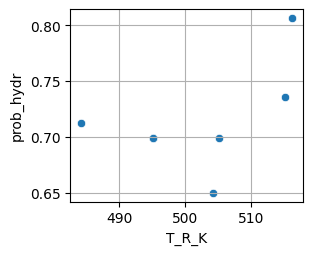

In [12]:
fig, ax = plt.subplots(figsize=(3,2.5))
sns.scatterplot(x='T_R_K', y='prob_hydr',
             data=prob_hydr.loc[prob_hydr['n_C'] == 2],
            ax = ax)

plt.grid('both')
# plt.legend(bbox_to_anchor=(1.02, 1))
# plt.ylim(0,1)

# plt.ylim(0,None)
# fig_name = 'T_vs_r_mass_T.pdf'
# # plt.savefig('/home/rafael/GoogleDrive/uem/Doutorado/Papers/SAF_kinetics/figures/'+fig_name, 
# #             bbox_inches = 'tight')
plt.show()

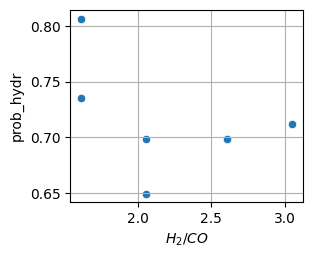

In [13]:
fig, ax = plt.subplots(figsize=(3,2.5))
sns.scatterplot(x='$H_2/CO$', y='prob_hydr',
             data=prob_hydr.loc[prob_hydr['n_C'] == 2],
            ax = ax)

plt.grid('both')
# plt.legend(bbox_to_anchor=(1.02, 1))
# plt.ylim(0,1)

# plt.ylim(0,None)
# fig_name = 'T_vs_r_mass_T.pdf'
# # plt.savefig('/home/rafael/GoogleDrive/uem/Doutorado/Papers/SAF_kinetics/figures/'+fig_name, 
# #             bbox_inches = 'tight')
plt.show()

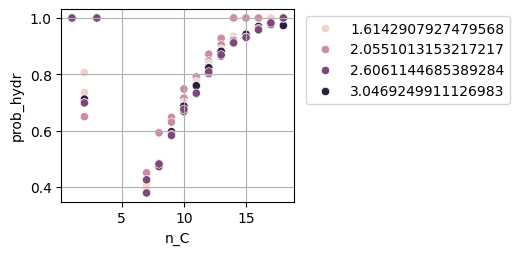

In [14]:
fig, ax = plt.subplots(figsize=(3,2.5))
sns.scatterplot(x='n_C', y='prob_hydr',
             data=prob_hydr,
            hue = '$H_2/CO$',
            ax = ax)

plt.grid('both')
plt.legend(bbox_to_anchor=(1.02, 1))
# plt.ylim(0,1)

# plt.ylim(0,None)
# fig_name = 'T_vs_r_mass_T.pdf'
# # plt.savefig('/home/rafael/GoogleDrive/uem/Doutorado/Papers/SAF_kinetics/figures/'+fig_name, 
# #             bbox_inches = 'tight')
plt.show()

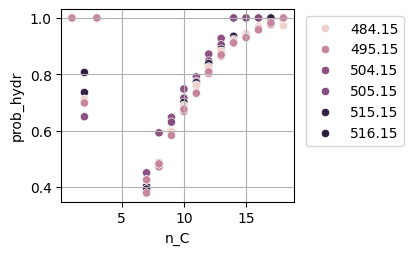

In [15]:
fig, ax = plt.subplots(figsize=(3,2.5))
sns.scatterplot(x='n_C', y='prob_hydr',
             data=prob_hydr,
            hue = 'T_R_K',
            ax = ax)

plt.grid('both')
plt.legend(bbox_to_anchor=(1.02, 1))
# plt.ylim(0,1)

# plt.ylim(0,None)
# fig_name = 'T_vs_r_mass_T.pdf'
# # plt.savefig('/home/rafael/GoogleDrive/uem/Doutorado/Papers/SAF_kinetics/figures/'+fig_name, 
# #             bbox_inches = 'tight')
plt.show()

In [16]:
# fitting the oleffin/paraffin ratio
def SSR_prob_hydr(params, prob_hydr):
    ssr = 0
    print(params)
    clear_output(wait=True)
    for i in range(len(prob_hydr)):
        T = prob_hydr['T_R_K'].iloc[i]
        H2_CO = prob_hydr['$H_2/CO$'].iloc[i]
        n = prob_hydr['n_C'].iloc[i]
        prob_hydr_model = 1/(1 + (1 - (n == 1) ) * e**(-(params[0] 
#                                        + params[1]*T 
#                                        + params[2]*H2_CO 
                                       + params[1]*n
                                       + params[2]*(prob_hydr['n_C'].iloc[i] == 2)
                                       + params[3]*(prob_hydr['n_C'].iloc[i] == 3)
                                      )))
        ssr = ssr + (prob_hydr['prob_hydr'].iloc[i] - prob_hydr_model)**2
    print(ssr)
    return ssr

In [17]:
beta_prob_hydr = [1, 
#                   1e-3, 
#                   1e-1, 
                  1e-1,
                  1,
                  1
                 ]

minimum_prob_hydr = minimize(SSR_prob_hydr, beta_prob_hydr, method = 'Nelder-Mead',
                               bounds = None,
    #                            options={'maxfev':max_fev}, 
                               args = (prob_hydr))
beta_prob_hydr = minimum_prob_hydr.x

0.07371697170811302


In [18]:
minimum_prob_hydr

       message: Optimization terminated successfully.
       success: True
        status: 0
           fun: 0.07371697170811298
             x: [-3.303e+00  4.139e-01  3.391e+00  2.101e+01]
           nit: 424
          nfev: 730
 final_simplex: (array([[-3.303e+00,  4.139e-01,  3.391e+00,  2.101e+01],
                       [-3.303e+00,  4.139e-01,  3.391e+00,  2.101e+01],
                       ...,
                       [-3.303e+00,  4.139e-01,  3.391e+00,  2.101e+01],
                       [-3.303e+00,  4.139e-01,  3.391e+00,  2.101e+01]],
                      shape=(5, 4)), array([ 7.372e-02,  7.372e-02,  7.372e-02,  7.372e-02,
                        7.372e-02]))

In [19]:
beta_prob_hydr

array([-3.30287087,  0.41389561,  3.39127209, 21.00726206])

In [20]:
n_C = list(range(1,36))

In [21]:
prob_hydr_model = [(1/(1 + (1 - (n_C == 1)) * e**(-(beta_prob_hydr[0] 
#                                             + beta_prob_hydr[1]*prob_hydr['T_R_K']
#                                             + beta_prob_hydr[2]*prob_hydr['$H_2/CO$']
                                            + beta_prob_hydr[1]*n_C
                                            + beta_prob_hydr[2]*(n_C == 2)
                                            + beta_prob_hydr[3]*(n_C == 3)
                                           ))))
                   for n_C in n_C
                  ]
prob_hydr['prob_hydr_model'] = (1/(1 + (1 - (prob_hydr['n_C'] == 1)) * e**(-(beta_prob_hydr[0] 
#                                             + beta_prob_hydr[1]*prob_hydr['T_R_K']
#                                             + beta_prob_hydr[2]*prob_hydr['$H_2/CO$']
                                            + beta_prob_hydr[1]*prob_hydr['n_C']
                                            + beta_prob_hydr[2]*(prob_hydr['n_C'] == 2)
                                            + beta_prob_hydr[3]*(prob_hydr['n_C'] == 3)
                                           ))))

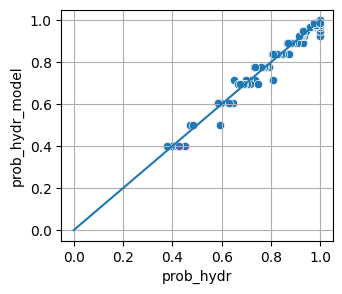

In [22]:
fig, ax = plt.subplots(figsize=(3.5,3))
sns.scatterplot(
                data=prob_hydr, 
                x="prob_hydr", 
                y="prob_hydr_model", 
#                 hue = '$H_2/CO$', size="n_C",
        #     sizes=(10, 200),
#                 palette = "bright",
                ax = ax,
#                 style='T_R_K',
)
plt.plot(np.linspace(0,
                     1,
                     num = 10), 
         np.linspace(0,
                     1,
                     num = 10))
plt.grid('both')
# plt.legend(bbox_to_anchor=(1.02, 1))
# plt.yscale('log')
# plt.xscale('log')
# plt.xlim(0,1)
# plt.ylim(0,1)
# fig_name = 'test_parity_F_out.pdf'
# plt.savefig('/home/rafael/GoogleDrive/uem/Doutorado/Papers/SAF_kinetics/figures/'+fig_name, bbox_inches = 'tight')

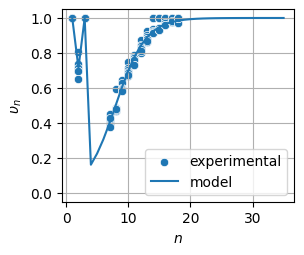

In [23]:
fig, ax = plt.subplots(figsize=(3,2.5))
sns.scatterplot(x='n_C', y='prob_hydr',
             data=prob_hydr,
#             hue = 'T_R_K',
            ax = ax, label = 'experimental')
plt.plot(n_C, prob_hydr_model, label = 'model')
plt.grid('both')
plt.legend()
plt.ylim(-0.05,1.05)
plt.xlabel('$n$')
plt.ylabel(r'$\upsilon_n$')
fig_name = 'upsilon_n.pdf'
# plt.savefig('/home/rafael/GoogleDrive/uem/Doutorado/Papers/SAF_kinetics/figures/'+fig_name, 
#             bbox_inches = 'tight')
plt.show()

In [24]:
upsilon = {}
for n_C in range(2,37):
    upsilon[n_C] = 1/(1 + (1 - (n_C == 1)) * e**(-(-3.303 + 0.4139*n_C + 3.391*(n_C == 2) + 21.01*(n_C == 3))))

In [25]:
1-upsilon[7]

0.6000563727296316